# Vision Transformer for Image Classification

## Goal

The purpose of this notebook is to demonstrate the main idea behind Vision Transformers.

Vision Transformers split an image into small patches and treat these patches as tokens, similar to words in Natural Language Processing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Image as Patches

Unlike CNNs, which use convolutional filters, Vision Transformers divide an image into fixed-size patches.

Each patch is treated as a token and passed into a Transformer encoder.

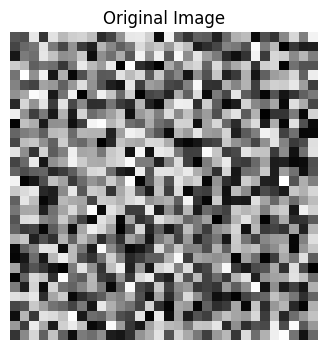

In [2]:
image = np.random.rand(32, 32)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

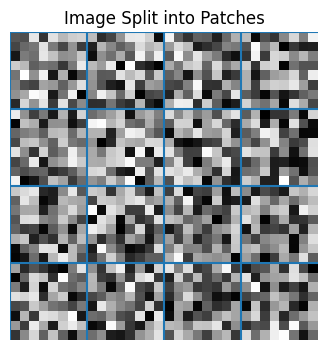

In [3]:
patch_size = 8

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")

for i in range(0, image.shape[0], patch_size):
    plt.axhline(i - 0.5)

for j in range(0, image.shape[1], patch_size):
    plt.axvline(j - 0.5)

plt.title("Image Split into Patches")
plt.axis("off")
plt.show()

## Extracting Patches

A Vision Transformer converts image patches into tokens.

Let's count how many patches are created from the image.

In [4]:
patches = []

for i in range(0, image.shape[0], patch_size):
    for j in range(0, image.shape[1], patch_size):
        patch = image[i:i+patch_size, j:j+patch_size]
        patches.append(patch)

print(f"Number of patches: {len(patches)}")
print(f"Patch shape: {patches[0].shape}")

Number of patches: 16
Patch shape: (8, 8)


## CNN vs Vision Transformer

CNNs and Vision Transformers process images differently.

CNNs rely on local filters and inductive biases.

Vision Transformers process image patches as tokens and learn relationships through self-attention.

In [5]:
cnn_features = [
    "Local receptive fields",
    "Translation equivariance",
    "Strong inductive bias"
]

vit_features = [
    "Image patches as tokens",
    "Self-attention",
    "Scales well with large datasets"
]

print("CNN:")
for item in cnn_features:
    print("-", item)

print("\nVision Transformer:")
for item in vit_features:
    print("-", item)

CNN:
- Local receptive fields
- Translation equivariance
- Strong inductive bias

Vision Transformer:
- Image patches as tokens
- Self-attention
- Scales well with large datasets


## Loading a Pretrained Vision Transformer

We can load a pretrained Vision Transformer model from Hugging Face.

The model was trained on ImageNet and already learned useful visual features.

In [11]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

from transformers import ViTModel

vit = ViTModel.from_pretrained(
    "google/vit-base-patch16-224"
)

print(type(vit))

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<class 'transformers.models.vit.modeling_vit.ViTModel'>


## Counting Parameters

Vision Transformers usually contain many more parameters than lightweight CNN models.

Let's count them.

In [8]:
vit_params = sum(
    p.numel()
    for p in vit.parameters()
)

print(f"Total parameters: {vit_params:,}")

Total parameters: 86,389,248


## Comparing ResNet18 and Vision Transformer

Both architectures can solve image classification tasks, but they process images differently.

ResNet uses convolutions, while Vision Transformers use self-attention.

In [9]:
from torchvision import models

resnet = models.resnet18(weights="DEFAULT")

resnet_params = sum(
    p.numel()
    for p in resnet.parameters()
)

print(f"ResNet18 parameters: {resnet_params:,}")
print(f"ViT parameters: {vit_params:,}")

ResNet18 parameters: 11,689,512
ViT parameters: 86,389,248


## Conclusion

Vision Transformers process images differently from convolutional neural networks.

Instead of applying convolutional filters, a Vision Transformer splits an image into patches and treats them as tokens.

These tokens are processed using self-attention mechanisms, allowing the model to learn global relationships across the image.

In this notebook we:

- Split an image into patches
- Extracted patch tokens
- Compared CNNs and Vision Transformers
- Loaded a pretrained ViT model
- Compared the number of parameters with ResNet18

Vision Transformers have become one of the most important architectures in modern computer vision.